**SVM - SVR**

In [1]:
# Importing the libraries
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import math
from numpy import arange
from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv('C:/MAFAS/APU/CT046-3-M-AML/CT046 - LABS/Python LAB MATERIALS/Lab 8 - SVM/kc_house_data.csv')
data

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [3]:
data = data.drop(['id', 'date', 'yr_renovated', 'zipcode', 'lat', 'long'], axis = 1)
data.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,1800,7503


In [4]:
data.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,sqft_living15,sqft_lot15
count,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,1986.552492,12768.455652
std,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,685.391304,27304.179631
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,399.000000,651.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,1490.000000,5100.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,1840.000000,7620.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,2360.000000,10083.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,6210.000000,871200.000000


In [5]:
data.isnull().sum()

price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
sqft_living15    0
sqft_lot15       0
dtype: int64

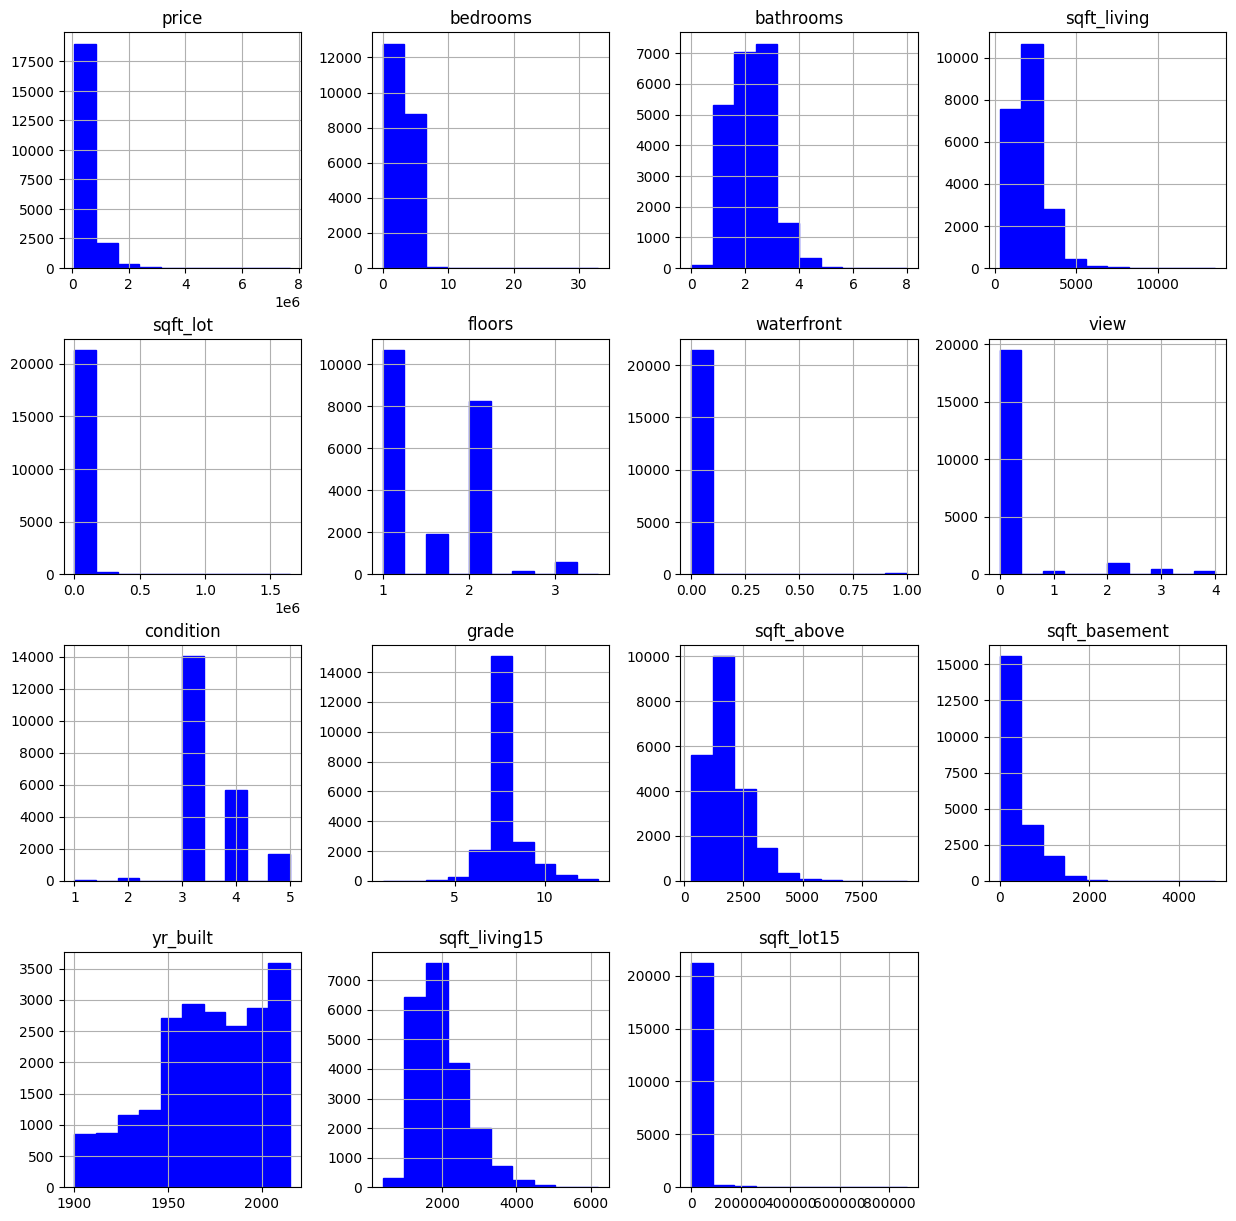

In [6]:
data.hist(figsize = (15,15), edgecolor = "blue", color = "blue")
plt.show()

In [7]:
x = data.iloc[:, 1:14].values
y = data.iloc[:, 0].values

In [8]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, random_state = 42)

In [9]:
sc = StandardScaler()
x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)

**SVR Base Model - RBF is the default kernel**

In [10]:
svr = SVR()
svr.fit(x_train_sc, y_train)
y_pred = svr.predict(x_test_sc)
mse = mean_squared_error(y_test, y_pred)
rmse = math.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 400760.34219872457
MAE: 229176.2624165978


**Using Linear Kernel**

In [47]:
grid_search_svr_lnr = GridSearchCV(estimator = SVR(kernel = 'linear'),
                       param_grid = {'C': arange(1, 5, 1),
                                   'epsilon': [0.0001, 0.001, 0.01, 0.1, 0.5, 1, 1.5],},
                       cv = 7, scoring = 'neg_mean_squared_error')

grid_result = grid_search_svr_lnr.fit(x_train_sc, y_train)

print("Best Parameters: ", grid_result.best_params_)
print("Best Score: ", math.sqrt(abs(grid_result.best_score_)))

best_svr_lnr = grid_result.best_estimator_

y_pred_lnr = best_svr_lnr.predict(x_test_sc)

mse_lnr = mean_squared_error(y_test, y_pred_lnr)
print("RMSE (Linear Kernel): ", math.sqrt(mse_lnr))

Best Parameters:  {'C': np.int64(4), 'epsilon': 0.0001}
Best Score:  305364.28183757566
RMSE (Linear Kernel):  323923.0749755576


**Using RBF Kernel**

In [11]:
grid_search_svr_rbf = GridSearchCV(estimator = SVR(kernel = 'rbf'),
                                    param_grid = {
                                                'C': arange(1, 5, 1),
                                                'epsilon': [0.0001, 0.001, 0.01, 0.1, 0.5, 1, 1.5],
                                                'gamma': [0.0001, 0.001, 0.01, 1, 2, 3]},
                                                cv = 7, scoring = 'neg_mean_squared_error')

grid_result = grid_search_svr_rbf.fit(x_train_sc, y_train)

print("Best Parameters: ", grid_result.best_params_)
print("Best Score: ", math.sqrt(abs(grid_result.best_score_)))

best_svr_rbf = grid_result.best_estimator_

y_pred_rbf = best_svr_rbf.predict(x_test_sc)

mse_rbf = mean_squared_error(y_test, y_pred_rbf)
print("RMSE (RBF Kernel): ", math.sqrt(mse_rbf))


Best Parameters:  {'C': np.int64(4), 'epsilon': 0.0001, 'gamma': 0.01}
Best Score:  370649.52399817755
RMSE (RBF Kernel):  399800.2334008454


**NOTE:**

Can try to perform HP tuning with all the kernels and other parameters.